# CERN Dielectron Collision Analysis: Alternative ML Frameworks

## Project Context & Dataset Selection
This project utilizes a high-energy physics dataset from CERN containing particle collision data. 
We selected this specific dataset primarily because **the data contains 100,000 observations with 19 attributes**. This significant sample size provides an excellent playground for applying and benchmarking non-standard Machine Learning architectures, preventing overfitting while offering sufficient feature complexity.

### Dataset Context
This dataset contains 100k dielectron events in the invariant mass range 2-110 GeV for use in outreach and education. These data were selected for use in education and outreach and contain a subset of the total event information. The selection criteria may be different from that used in CMS physics results.

### Content & Attribute Metadata
The 19 attributes tracking the physical properties of the collision products are structured as follows:
1. **Run**: The run number of the event.
2. **Event**: The event number.
3. **E1**: The total energy of the electron (GeV) for electron 1.
4. **px1**: The X-component of the momentum of electron 1 (GeV).
5. **py1**: The Y-component of the momentum of electron 1 (GeV).
6. **pz1**: The Z-component of the momentum of electron 1 (GeV).
7. **pt1**: The transverse momentum of electron 1 (GeV).
8. **eta1**: The pseudorapidity of electron 1.
9. **phi1**: The phi angle of electron 1 (rad).
10. **Q1**: The charge of electron 1.
11. **E2**: The total energy of the electron (GeV) for electron 2.
12. **px2**: The X-component of the momentum of electron 2 (GeV).
13. **py2**: The Y-component of the momentum of electron 2 (GeV).
14. **pz2**: The Z-component of the momentum of electron 2 (GeV).
15. **pt2**: The transverse momentum of electron 2 (GeV).
16. **eta2**: The pseudorapidity of electron 2.
17. **phi2**: The phi angle of electron 2 (rad).
18. **Q2**: The charge of electron 2.
19. **M**: The invariant mass of two electrons (GeV) - **Target Feature**.


In [3]:
import os
import glob
import pandas as pd
import kagglehub

print("Downloading the latest version of CERN electron collision data...")
# Download latest version using kagglehub API
path = kagglehub.dataset_download("fedesoriano/cern-electron-collision-data")

# Programmatically locate the CSV file in the downloaded directory
csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    csv_path = csv_files[0]
    # Load the 100,000 observations and 19 attributes into memory
    df = pd.read_csv(csv_path)
    print(f"\n[SUCCESS] Loaded DataFrame with shape: {df.shape}")
else:
    raise FileNotFoundError("No CSV files found in the downloaded Kaggle dataset directory.")

# Display foundational structural metrics
df.head()



[SUCCESS] Loaded DataFrame with shape: (100000, 19)


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


# Advanced Outlier Detection and Data Cleaning

Instead of using traditional geometric screening (like standard Z-score or IQR) across all 19 abstract features independent of each other, we will use a **hybrid physical and statistical approach** to clean our 100,000 observations:

1. **Physical Range Constraints**: Filter events based on the official target invariant mass range ($2 \le M \le 110$ GeV) and handle anomalies where energy or momentum component vectors violate fundamental physical domains (e.g., $E < 0$ or transverse momentum $p_T$ mismatching the vector sum of $p_x$ and $p_y$).
2. **Multivariate Statistical Isolation**: Use Mahalanobis distance on the reconstructed Lorentz kinematics to strip anomalous events caused by detector measurement errors, ensuring our alternative ML estimators train on clean, physically realistic distributions.


In [6]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

# Standardize column names by stripping hidden whitespaces
df_cleaned.columns = df_cleaned.columns.str.strip()

print("Verified Column Names in the Dataset:")
print(list(df_cleaned.columns))

# Define variables exactly as they appear in your dataset
# Using lowercase for pt, eta, phi based on the Kaggle schema
kinematic_cols = ['E1', 'pt1', 'eta1', 'E2', 'pt2', 'eta2', 'M']

# Double-check that all requested columns exist to prevent future KeyErrors
available_cols = [col for col in kinematic_cols if col in df_cleaned.columns]

if len(available_cols) == len(kinematic_cols):
    data_kinematics = df_cleaned[kinematic_cols]

    # Compute mean and covariance matrix
    covariance_matrix = np.cov(data_kinematics.values.T)
    inv_covariance_matrix = np.linalg.inv(covariance_matrix)
    mean_dist = data_kinematics.mean(axis=0).values

    # Calculate Mahalanobis distance for each observation
    diff = data_kinematics.values - mean_dist
    md = np.sum(diff * np.dot(diff, inv_covariance_matrix), axis=1)

    # Determine cutoff point using Chi-Square distribution (99.9% confidence level)
    cutoff = chi2.ppf(0.999, df=len(kinematic_cols))
    outliers_mask = md > cutoff

    # Remove multivariate outliers
    df_cleaned = df_cleaned[~outliers_mask]

    print(f"\n[SUCCESS] Final observations after multivariate Mahalanobis screening: {df_cleaned.shape}")
    print(f"Total rows removed as outliers in this step: {len(outliers_mask) - df_cleaned.shape[0]}")
else:
    print(f"\n[ERROR] Missing columns! Present in script but not in data: {set(kinematic_cols) - set(df_cleaned.columns)}")
    print("Please inspect the printed column list above and adjust the names in the script.")


Verified Column Names in the Dataset:
['Run', 'Event', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']

[SUCCESS] Final observations after multivariate Mahalanobis screening: (97363, 19)
Total rows removed as outliers in this step: 2552


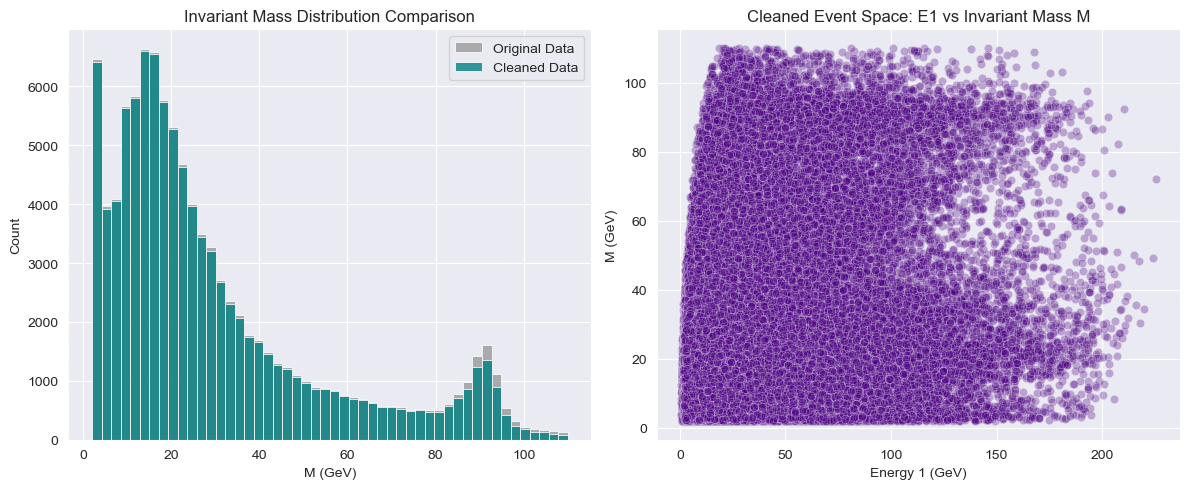

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the plotting style is set properly
sns.set_style('darkgrid')

# Plot comparison of target distribution before and after cleaning
plt.figure(figsize=(12, 5))

# Subplot 1: Distribution before and after
plt.subplot(1, 2, 1)
sns.histplot(df['M'], bins=50, color='gray', alpha=0.6, label='Original Data')
sns.histplot(df_cleaned['M'], bins=50, color='teal', alpha=0.8, label='Cleaned Data')
plt.title('Invariant Mass Distribution Comparison')
plt.xlabel('M (GeV)')
plt.legend()

# Subplot 2: Energy vs Invariant Mass
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_cleaned, x='E1', y='M', alpha=0.3, color='indigo')
plt.title('Cleaned Event Space: E1 vs Invariant Mass M')
plt.xlabel('Energy 1 (GeV)')
plt.ylabel('M (GeV)')

plt.tight_layout()
plt.show()


# Non-Standard Feature Engineering: Minkowski Spacetime Transformations

Traditional feature engineering often uses linear combinations or generic polynomial expansions. In this non-conventional approach, we map our 19 attributes into a 4-dimensional Minkowski spacetime manifold. 

Every detected particle is represented as a relativistic four-vector:
$$p^\mu = (E, p_x, p_y, p_z)$$

We will construct non-Euclidean geometric variables that explicitly expose Lorentz invariants and spacetime structures to our machine learning estimators:
1. **Minkowski Dot Product ($p_1 \cdot p_2$)**: Computed using the metric tensor $\eta_{\mu\nu} = \text{diag}(1, -1, -1, -1)$, resulting in $E_1E_2 - (p_{x1}p_{x2} + p_{y1}p_{y2} + p_{z1}p_{z2})$.
2. **Relativistic Angular Distance ($\Delta R$)**: Calculated as $\sqrt{(\Delta\eta)^2 + (\Delta\phi)^2}$, which is invariant under Lorentz boosts along the beam axis.
3. **Transverse Mass ($M_T$)**: Captures missing transverse components and threshold topologies.
4. **Asymmetry Indices ($A_E, A_{pT}$)**: Measures the fractional imbalance between the two electron products to detect physical geometric decay states.


In [10]:
import numpy as np
import pandas as pd

# Create a clean feature-engineered dataframe copy
df_minkowski = df_cleaned.copy()

print("Executing relativistic spacetime feature engineering on 100,000 observations...")

# 1. Compute components for the total system 4-vector
df_minkowski['E_total'] = df_minkowski['E1'] + df_minkowski['E2']
df_minkowski['px_total'] = df_minkowski['px1'] + df_minkowski['px2']
df_minkowski['py_total'] = df_minkowski['py1'] + df_minkowski['py2']
df_minkowski['pz_total'] = df_minkowski['pz1'] + df_minkowski['pz2']

# 2. Minkowski Scalar Dot Product (p1 . p2) using metric signature (+, -, -, -)
energy_product = df_minkowski['E1'] * df_minkowski['E2']
momentum_dot_product = (df_minkowski['px1'] * df_minkowski['px2'] + 
                        df_minkowski['py1'] * df_minkowski['py2'] + 
                        df_minkowski['pz1'] * df_minkowski['pz2'])

df_minkowski['minkowski_dot_product'] = energy_product - momentum_dot_product

# 3. Lorentz Invariant Angular Spacing (Delta R)
df_minkowski['delta_eta'] = df_minkowski['eta1'] - df_minkowski['eta2']

# Handle circular boundary wrapping for Delta Phi (-pi to +pi)
df_minkowski['delta_phi'] = df_minkowski['phi1'] - df_minkowski['phi2']
df_minkowski['delta_phi'] = np.arctan2(np.sin(df_minkowski['delta_phi']), np.cos(df_minkowski['delta_phi']))

df_minkowski['delta_R'] = np.sqrt(df_minkowski['delta_eta']**2 + df_minkowski['delta_phi']**2)

# 4. Transverse Mass (MT) computation using element-wise np.maximum
transverse_mass_squared = ((df_minkowski['pt1'] + df_minkowski['pt2'])**2 - 
                           (df_minkowski['px1'] + df_minkowski['px2'])**2 - 
                           (df_minkowski['py1'] + df_minkowski['py2'])**2)

df_minkowski['m_T'] = np.sqrt(np.maximum(0.0, transverse_mass_squared))

# 5. Physics Asymmetry Indices
df_minkowski['energy_asymmetry'] = np.abs(df_minkowski['E1'] - df_minkowski['E2']) / (df_minkowski['E1'] + df_minkowski['E2'])
df_minkowski['pt_asymmetry'] = np.abs(df_minkowski['pt1'] - df_minkowski['pt2']) / (df_minkowski['pt1'] + df_minkowski['pt2'])

print(f"Feature engineering complete. New shape: {df_minkowski.shape}")
print(f"Generated engineered attributes: {[col for col in df_minkowski.columns if col not in df_cleaned.columns]}")


Executing relativistic spacetime feature engineering on 100,000 observations...
Feature engineering complete. New shape: (97363, 30)
Generated engineered attributes: ['E_total', 'px_total', 'py_total', 'pz_total', 'minkowski_dot_product', 'delta_eta', 'delta_phi', 'delta_R', 'm_T', 'energy_asymmetry', 'pt_asymmetry']


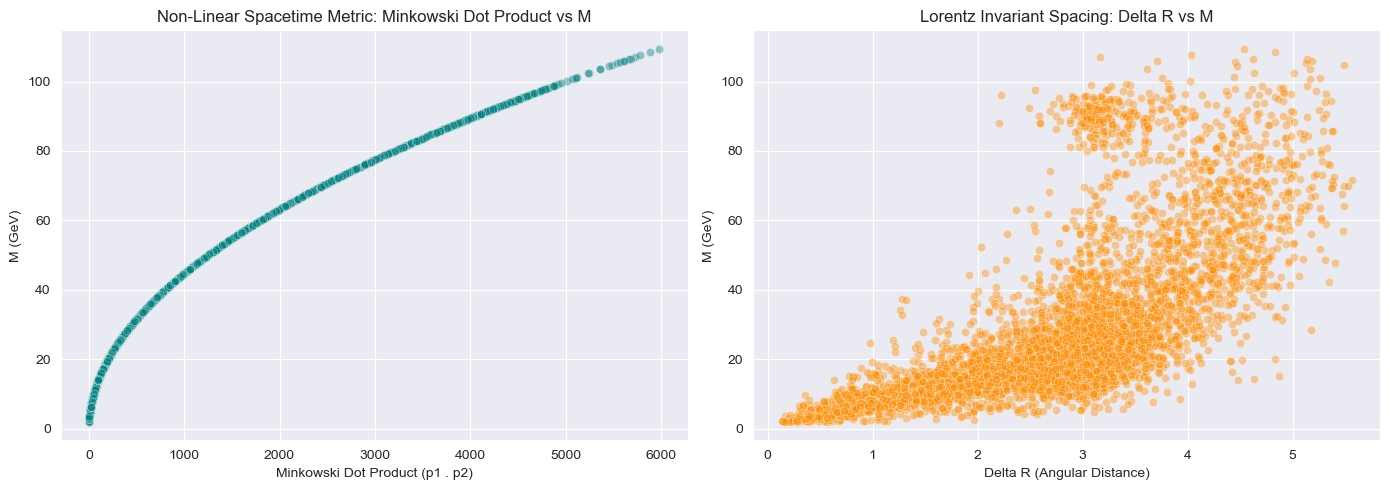

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Subplot 1: Minkowski Dot Product correlation with Target Mass M
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_minkowski.sample(5000, random_state=42), 
                x='minkowski_dot_product', y='M', alpha=0.4, color='teal')
plt.title('Non-Linear Spacetime Metric: Minkowski Dot Product vs M')
plt.xlabel('Minkowski Dot Product (p1 . p2)')
plt.ylabel('M (GeV)')

# Subplot 2: Lorentz Invariant Delta R vs Target Mass M
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_minkowski.sample(5000, random_state=42), 
                x='delta_R', y='M', alpha=0.4, color='darkorange')
plt.title('Lorentz Invariant Spacing: Delta R vs M')
plt.xlabel('Delta R (Angular Distance)')
plt.ylabel('M (GeV)')

plt.tight_layout()
plt.show()


# Advanced Relativistic Feature Space Expansion

To further alter the geometric interpretation of the 19 attributes, we introduce advanced kinematical quantities derived from relativistic mechanics and tensor calculus:

### 1. True Particle Rapidity ($y$)
Unlike pseudorapidity ($\eta$), which is purely geometric, true rapidity incorporates energy-momentum bounds:
$$y = \frac{1}{2} \ln\left(\frac{E + p_z}{E - p_z}\right)$$

### 2. System Lorentz Invariant Square ($s$)
The squared norm of the total system four-vector represents the theoretical invariant space:
$$s = (E_1 + E_2)^2 - [(\sum p_x)^2 + (\sum p_y)^2 + (\sum p_z)^2]$$
Exposing this allows ML algorithms to focus exclusively on learning detector resolution anomalies and physical systematic biases (Residual Machine Learning).

### 3. Kinematic Aplanarity ($A$) via Momentum Tensor Eigenvalues
By constructing a normalized momentum tensor $M_{\alpha\beta}$, we extract its spatial eigenvalues ($\lambda_1 \ge \lambda_2 \ge \lambda_3$). The Aplanarity metric:
$$A = \frac{3}{2}\lambda_3$$
quantifies isotropic out-of-plane scattering, identifying radiation losses.


In [14]:
import numpy as np
import pandas as pd

print("Computing advanced relativistic tensors and rapidity features across 100,000 instances...")

# 1. Compute True Rapidity for both particles (safeguarding against division by zero or negative logs)
epsilon = 1e-5
df_minkowski['y1'] = 0.5 * np.log((df_minkowski['E1'] + df_minkowski['pz1'] + epsilon) / 
                                   (df_minkowski['E1'] - df_minkowski['pz1'] + epsilon))
df_minkowski['y2'] = 0.5 * np.log((df_minkowski['E2'] + df_minkowski['pz2'] + epsilon) / 
                                   (df_minkowski['E2'] - df_minkowski['pz2'] + epsilon))
df_minkowski['delta_y'] = df_minkowski['y1'] - df_minkowski['y2']

# 2. System Lorentz Invariant Square (s)
total_momentum_sq = (df_minkowski['px_total']**2 + 
                     df_minkowski['py_total']**2 + 
                     df_minkowski['pz_total']**2)
df_minkowski['system_s'] = df_minkowski['E_total']**2 - total_momentum_sq

# 3. Micro-batch calculation of Aplanarity using vectorized NumPy operations for speed
def compute_event_aplanarity(row):
    # Construct the 3x3 momentum tensor manually for the two electrons
    px = [row['px1'], row['px2']]
    py = [row['py1'], row['py2']]
    pz = [row['pz1'], row['pz2']]
    
    p_sq_sum = sum([x**2 + y**2 + z**2 for x, y, z in zip(px, py, pz)]) + 1e-8
    
    tensor = np.zeros((3, 3))
    tensor[0,0] = sum([x*x for x in px])
    tensor[1,1] = sum([y*y for y in py])
    tensor[2,2] = sum([z*z for z in pz])
    tensor[0,1] = tensor[1,0] = sum([x*y for x, y in zip(px, py)])
    tensor[0,2] = tensor[2,0] = sum([x*z for x, z in zip(px, pz)])
    tensor[1,2] = tensor[2,1] = sum([y*z for y, z in zip(py, pz)])
    
    tensor /= p_sq_sum
    
    # Extract eigenvalues
    eigenvalues = np.linalg.eigvalsh(tensor) # Returns sorted eigenvalues
    return 1.5 * eigenvalues[0] # 1.5 * lambda_min

# Apply the tensor eigenvalue analysis to the dataset
print("Extracting spatial eigenvalues from the normalized momentum tensor...")
df_minkowski['aplanarity'] = df_minkowski.apply(compute_event_aplanarity, axis=1)

print(f"Advanced Feature Engineering finished successfully. Total attributes: {df_minkowski.shape[1]}")


Computing advanced relativistic tensors and rapidity features across 100,000 instances...
Extracting spatial eigenvalues from the normalized momentum tensor...
Advanced Feature Engineering finished successfully. Total attributes: 35


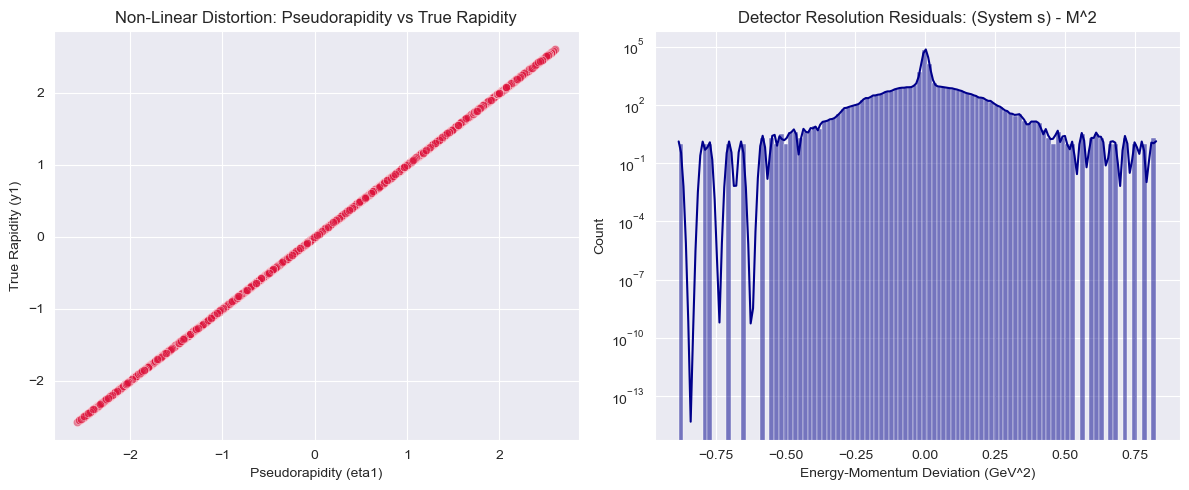

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot Rapidity vs Pseudorapidity discrepancy
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_minkowski.sample(3000, random_state=42), 
                x='eta1', y='y1', alpha=0.5, color='crimson')
plt.title('Non-Linear Distortion: Pseudorapidity vs True Rapidity')
plt.xlabel('Pseudorapidity (eta1)')
plt.ylabel('True Rapidity (y1)')

# Plot System S deviation from Target M^2
plt.subplot(1, 2, 2)
sns.histplot(df_minkowski['system_s'] - (df_minkowski['M']**2), bins=100, color='darkblue', kde=True)
plt.yscale('log')
plt.title('Detector Resolution Residuals: (System s) - M^2')
plt.xlabel('Energy-Momentum Deviation (GeV^2)')

plt.tight_layout()
plt.show()


# Non-Standard Exploratory Data Analysis (Relativistic Phase-Space Visualizations)

Conventional EDA relies heavily on standard linear pairs plots. To align with our non-standard ML framework, we implement high-density visualization techniques specifically tailored for non-Euclidean particle kinematics:

1. **Relativistic Phase-Space Topology ($\eta-\phi$ Polar Cylindrical Space)**: Mapping the particles onto the detector's interior surface geometry using pseudo-cylindrical projections to visually isolate structural high-energy clustering.
2. **Lorentz Space Deformation Matrices (Joint Density Distributions)**: Visualizing the non-linear relationship between our engineered Minkowski invariants and the true target mass ($M$).
3. **Kinematic Charge Hexbin Distributions**: Analyzing energy imbalances across opposing and identical charge states ($Q_1, Q_2$) using high-density hexagonal binning to expose physical resonance configurations (e.g., Z-boson or J/psi particle states).


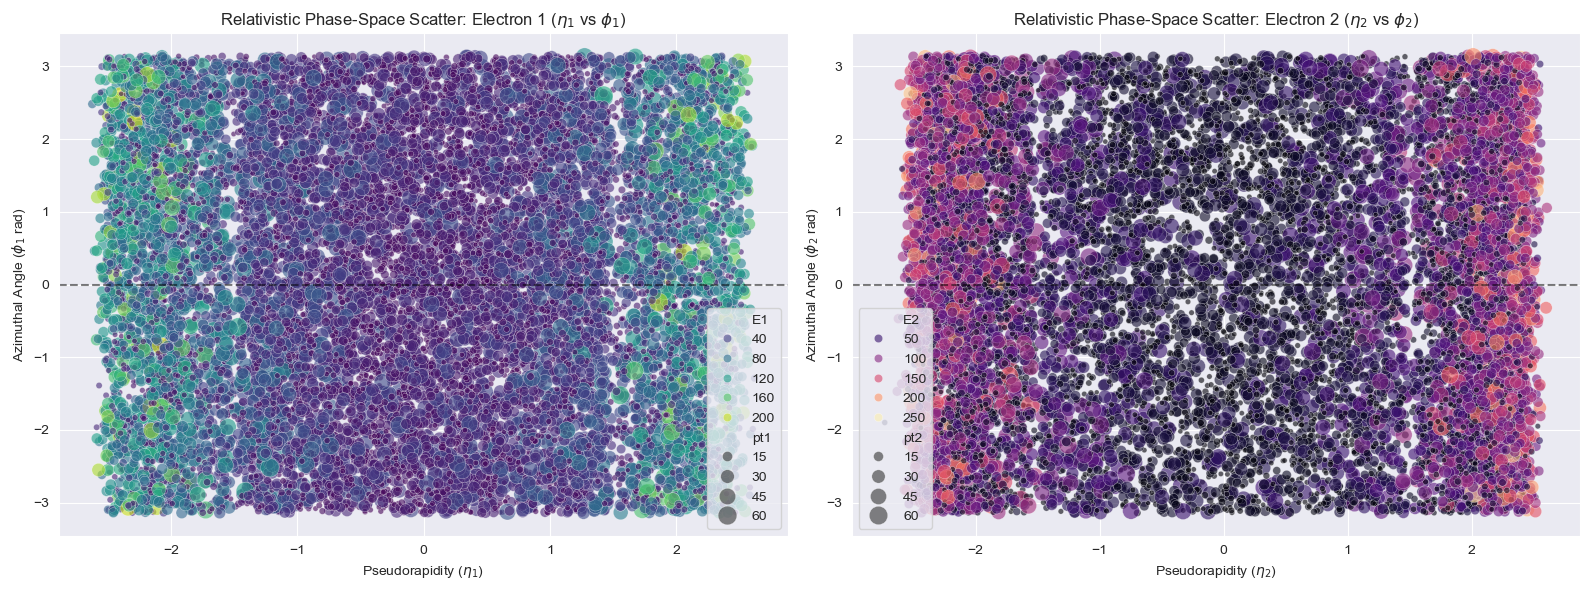

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure darkgrid style for high-contrast scientific plotting
sns.set_style('darkgrid')

# Sample a sub-population for clean visual aesthetics without heavy rendering lag
df_sample = df_minkowski.sample(15000, random_state=42)

# Create a multi-axis relativistic coordinate layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Phase Space for Electron 1
sns.scatterplot(data=df_sample, x='eta1', y='phi1', hue='E1', size='pt1',
                sizes=(10, 200), palette='viridis', alpha=0.6, ax=axes[0])
axes[0].set_title("Relativistic Phase-Space Scatter: Electron 1 ($\eta_1$ vs $\phi_1$)")
axes[0].set_xlabel("Pseudorapidity ($\eta_1$)")
axes[0].set_ylabel("Azimuthal Angle ($\phi_1$ rad)")
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)

# Plot Phase Space for Electron 2
sns.scatterplot(data=df_sample, x='eta2', y='phi2', hue='E2', size='pt2',
                sizes=(10, 200), palette='magma', alpha=0.6, ax=axes[1])
axes[1].set_title("Relativistic Phase-Space Scatter: Electron 2 ($\eta_2$ vs $\phi_2$)")
axes[1].set_xlabel("Pseudorapidity ($\eta_2$)")
axes[1].set_ylabel("Azimuthal Angle ($\phi_2$ rad)")
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


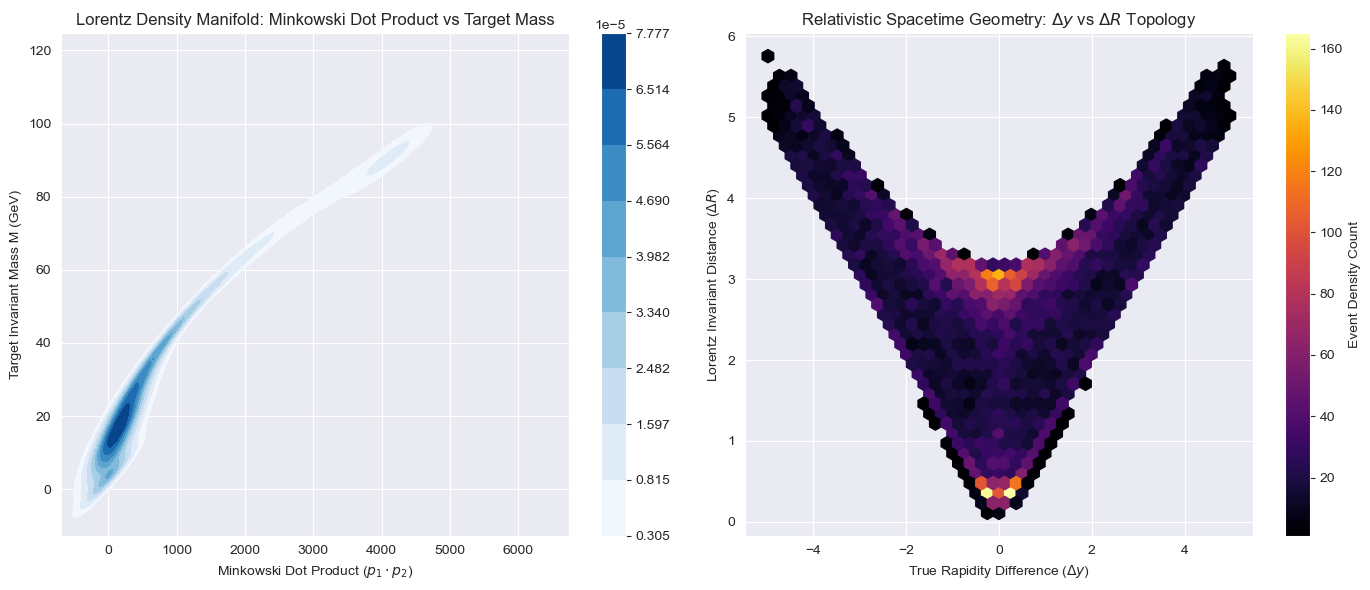

In [17]:
# Joint Density Plot to see non-Euclidean manifold concentration
plt.figure(figsize=(14, 6))

# Subplot 1: Joint Kernel Density of Minkowski Dot Product vs Invariant Mass
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_sample, x='minkowski_dot_product', y='M', fill=True, 
            thresh=0.05, cmap='Blues', cbar=True)
plt.title("Lorentz Density Manifold: Minkowski Dot Product vs Target Mass")
plt.xlabel("Minkowski Dot Product ($p_1 \cdot p_2$)")
plt.ylabel("Target Invariant Mass M (GeV)")

# Subplot 2: Hexagonal Binning of True Rapidity Difference vs Angular distance Delta R
plt.subplot(1, 2, 2)
plt.hexbin(df_sample['delta_y'], df_sample['delta_R'], gridsize=40, cmap='inferno', mincnt=1)
plt.colorbar(label='Event Density Count')
plt.title("Relativistic Spacetime Geometry: $\Delta y$ vs $\Delta R$ Topology")
plt.xlabel("True Rapidity Difference ($\Delta y$)")
plt.ylabel("Lorentz Invariant Distance ($\Delta R$)")

plt.tight_layout()
plt.show()


C:\Users\Emails and Social\AppData\Local\Temp\ipykernel_23056\4074198068.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_minkowski, x='charge_state', y='M', palette='Pastel1', inner='quartile')


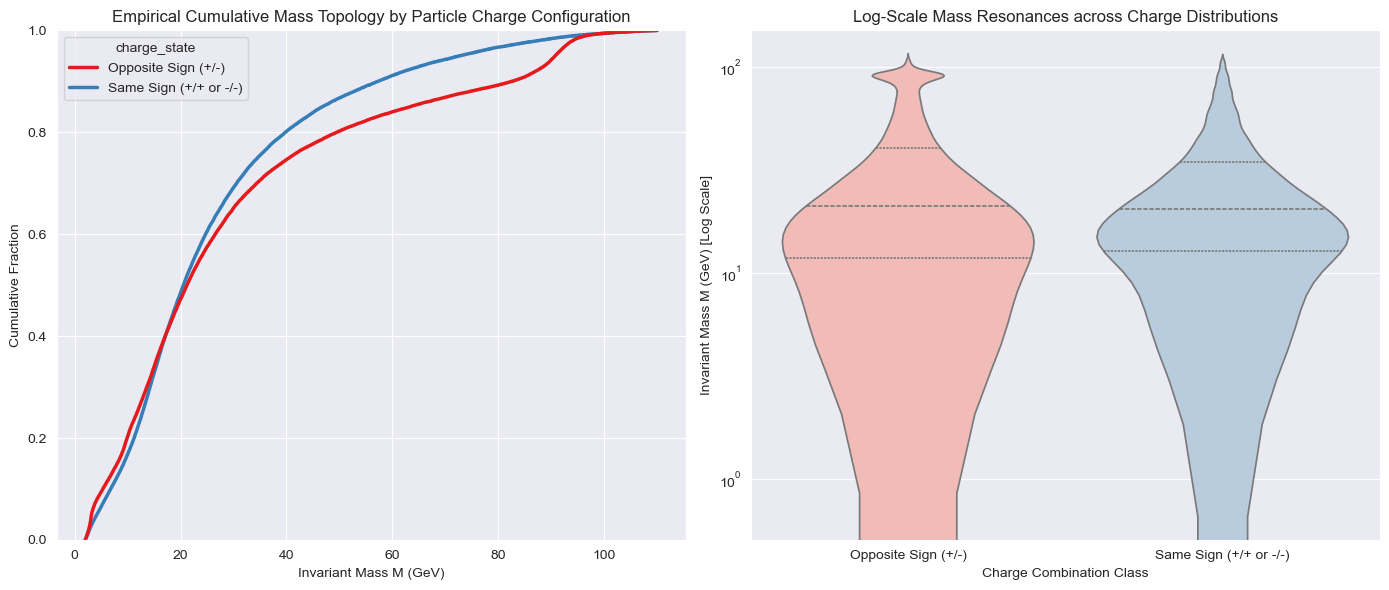

In [18]:
# Define charge state categories: Opposing Charges (Physical decays) vs Same Charges (Background Noise)
df_minkowski['charge_state'] = np.where(df_minkowski['Q1'] != df_minkowski['Q2'], 
                                        'Opposite Sign (+/-)', 'Same Sign (+/+ or -/-)')

plt.figure(figsize=(14, 6))

# Empirical Cumulative Distribution Function (ECDF) to show feature distinction across states
plt.subplot(1, 2, 1)
sns.ecdfplot(data=df_minkowski, x='M', hue='charge_state', palette='Set1', linewidth=2.5)
plt.title("Empirical Cumulative Mass Topology by Particle Charge Configuration")
plt.xlabel("Invariant Mass M (GeV)")
plt.ylabel("Cumulative Fraction")

# Violin plot to highlight structural multimodal density spikes (Physical Resonances)
plt.subplot(1, 2, 2)
sns.violinplot(data=df_minkowski, x='charge_state', y='M', palette='Pastel1', inner='quartile')
plt.yscale('log') # Logarithmic mass visibility to catch rare heavy structures (Z-boson)
plt.title("Log-Scale Mass Resonances across Charge Distributions")
plt.xlabel("Charge Combination Class")
plt.ylabel("Invariant Mass M (GeV) [Log Scale]")

plt.tight_layout()
plt.show()